# Демонстрация cред из библиотеки gymnasium

Для демонстрации работы изучаемых алгоримтов будем использовать готовые среды из библиотеки `gymnasium` (ранее OpenAI Gym). 

https://gymnasium.farama.org/

In [1]:
!python --version

Python 3.13.9


Для рендеринга некоторых сред библиотеки `gymnasium` потреуется пакет `box2d-py` (пока работает только в Python версии до 3.14.x). Для `box2d-py` требуется библиотека `swig`. Их можно поставить через командую строку дистрибутива Anaconda3. 

    conda install swig -c conda-forge
    conda install box2d-py -c conda-forge 

Также при установке библиотеки `swig` может потребовать установить Microsoft C++ Build Tools 

(см. подробнее https://www.youtube.com/watch?v=gMgj4pSHLww, в этом же видео можно найти настройки работы с библиотекой `gymnasium` в Visual Studio).

Теперь, перезагрузив ядро, можно установить библиотеку `gymnasium` со всеми подпакетами

    pip install gymnasium[all]

In [1]:
!pip install gymnasium[all]

  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
  Using cached ale_py-0.12.0-cp313-cp313-win_amd64.whl.metadata (10.0 kB)
  Using cached box2d_py-2.3.5-cp313-cp313-win_amd64.whl
  Using cached pygame_ce-2.5.7-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached mujoco-3.11.0-cp313-cp313-win_amd64.whl.metadata (237 kB)
  Using cached jax-0.11.0-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.11.0-cp313-cp313-win_amd64.whl.metadata (1.3 kB)
  Using cached flax-0.12.8-py3-none-any.whl.metadata (11 kB)
  Using cached array_api_compat-1.15.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached torch-2.13.0-cp313-cp313-win_amd64.whl.metadata (39 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached optax-0.2.8-py3-none-any.whl.metadata (7.9 kB)
  Using cached orbax_checkpoint-0.

  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'D:\\anaconda3\\Lib\\site-packages\\orbax\\checkpoint\\experimental\\v1\\_src\\testing\\compatibility\\checkpoints\\v0_checkpoints\\composite_checkpoint\\checkpoint_metadata_missing\\pytree_checkpointable_missing_metadata\\state\\ocdbt.process_0\\d\\60c4009561fe85efe8a0afa099989378'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [2]:
# загрузка библиотеки gymnasium
import gymnasium as gym
gym.__version__

'1.3.0'

Создание экземпляра среды с названием `EnvTitle` осуществляется командой

    env = gym.make('EnvTitle')

Основные методы:

    env.reset()  помещает среду в начальное состояние
    env.render() визуализация состояния среды
    env.step()   сделать действие и получить новое состояние среды
    env.close()  завершение работы со средой

Получить описание пространства состояний и действий для выбранной среды можно командами

    env.observation_space
    env.action_space

В частности, выдать случаное состояние или действие можно командами

    env.observation_space.sample()
    env.action_space.sample()

Рассмотрим некоторые среды, которые будут использоваться далее. Для этих сред:

- напечатаем начальное состояние;
- напечатаем информацию о пространстве состояний и действий;
- запустим симуляцию работы среды, выбирая действия случайным образом.

### Среда FrozenLake

Это простая среда о нахождении правильного пути на клеточном поле.

In [3]:
# создание экземпляра среды
env = gym.make('FrozenLake-v1')

# обнуление среды и получение начального состояния
state, _ = env.reset()
print("Начальное состояние:", state)

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

Начальное состояние: 0
Пространство состояний: Discrete(16)
Пространство действий: Discrete(4)


Для данной среды пространство состояний имеет вид `Discrete(16)`. Это значит среда имеет 16 дискретных состояний.
Пространство действий имеет вид `Discrete(4)`. Это значит агенту доступно 4 дискретных действия.

Запустим симуляцию среды со случайными действями. Для выбора случайного действия можно использовать команду 

    action = env.action_space.sample()
    
Для перехода к новому состоянию среды по сделанному действию и текущему состоянию используется команда `env.step(action)`.
Эта команда возвращает кортеж из 5 аргументов: 

    (новое состояние, 
    вознаграждение, 
    флаг о достижении заключительного состояния, 
    флаг об остановке взаимодействия по времени, 
    прочая информация).

In [4]:
# создание симуляции с автоматическим рендерингом изображения
env = gym.make('FrozenLake-v1', render_mode = 'human')
# обнуление среды и получение начального состояния
state, _ = env.reset()

# для записи дохода
gain = 0

while True:
    # выбор действия
    action = env.action_space.sample()
    # совершение действия и переход среды к новому состоянию, 
    # получение вознаграждения и автоматический рендер изображения
    state, reward, terminated, truncated, info = env.step(action)
    # обновление дохода
    gain += reward
    # проверка флагов о конце эпизода
    if terminated or truncated:
        break
    
print("Доход:", gain)
# завершить взаимодействие со средой, закрыть окно с рендером
env.close()

Доход: 0


Чтобы создать среду без автоматического рендеринга изображения можно использовать команду

    env = gym.make('FrozenLake-v1', render_mode = None)

или просто

    env = gym.make('FrozenLake-v1')

так как параметр `render_mode` имеет по умолчанию значение `None`. 

Ряд простых сред можно также запустить с упрощённым рендерингом в текстовом формате. Для этого при создании среды надо указать параметр `render_mode="ansi"`. Приведём пример запуска симуляции с таким способом рендеринга.

In [5]:
# подгрузка дополнительных библиотек
import time
from IPython.display import clear_output

# создание симуляции с упрощённым рендерингом изображения
env = gym.make('FrozenLake-v1', render_mode="ansi")
state, _ = env.reset()
# печать начального состояния
print(env.render())

gain = 0

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)  
    gain += reward
    
    # печать упрощённого рендеринга
    time.sleep(.2)
    clear_output(wait=True)
    print(env.render())

    if terminated or truncated:
        break
    
print("Доход:", gain)
env.close() 

  (Left)
SFFF
FHFH
FFFH
HFFG

Доход: 0


**Цель агента** в этой среде заключается в том, чтобы провести агента по льду от старта до цели.

### Среда Taxi

Рассмотрим ещё одну простую среду о передвижении агента в клеточном поле с дополнительными действиями.

In [14]:
# создание экземпляра среды
env = gym.make('Taxi-v4')

# обнуление среды и получение начального состояния
state, _ = env.reset()
print("Начальное состояние:", state)

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

Начальное состояние: 281
Пространство состояний: Discrete(500)
Пространство действий: Discrete(6)


Пространство состояний состоит из 500 дискретных состояний. Агенту доступно 6 дискретных действий. Запустим симуляцию среды со случайными действями. 

При создании среды можно использовать дополнительные классы-обёртки для среды. См. подробности:

https://gymnasium.farama.org/api/wrappers/

Добавим обёртку для автоматического слежения за показателем дохода за эпизод. Доход записывается в специальную структуру данных - очередь (англ. queue).

In [6]:
# ограничим длительность взаимодействия 50 шагами
env = gym.make('Taxi-v4', render_mode = 'human', max_episode_steps=50)
# добавление обёртки
env = gym.wrappers.RecordEpisodeStatistics(env)

state, _ = env.reset()

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
    
print("Доход:", env.return_queue)
env.close()

Доход: deque([-194.0], maxlen=100)


**Цель агента** в том, чтобы, управляя такси, подобрать пассажира и довезти его до места назначения.

### Среда MountainCar

Рассмотрим среду с непрерывным пространством состояний.

In [17]:
# создание экземпляра среды
env = gym.make('MountainCar-v0')

# обнуление среды и получение начального состояния
state, _ = env.reset()
print("Начальное состояние:", state)

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

Начальное состояние: [-0.5477326  0.       ]
Пространство состояний: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Пространство действий: Discrete(3)


Для этой среды пространство состояний имеет вид 

    Box([-1.2  -0.07], [0.6  0.07], (2,), float32) 
    
Третий аргумент `(2,)` указывает на то, сколько параметров задают состояние. В данном случае их два. 

Первые два аргумента отвечают за интервалы, в которых эти параметры могут непрерывно изменяться. Более подробно, первые координаты у списков `[-1.2  -0.07], [0.6  0.07]` указывают интервал `[-1.2, 0.6]`, где может меняться первый параметр состояния и аналогичным образом в интервале `[-0.07, 0.07]` изменяется второй параметр.

In [18]:
env = gym.make('MountainCar-v0', render_mode = 'human')
env = gym.wrappers.RecordEpisodeStatistics(env)
state, _ = env.reset()

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
    
print("Доход:", env.return_queue)
env.close()

Доход: deque([-200.0], maxlen=100)


**Цель агента** в том, чтобы втолкнуть машину на вершину холма справа.

### Среда CartPole

Рассмотрим ещё одну среду с непрерывным пространством состояний, основанную на задаче об удержании обратного маятника.

In [19]:
# создание экземпляра среды
env = gym.make('CartPole-v1')

# обнуление среды и получение начального состояния
state, _ = env.reset()

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

Пространство состояний: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Пространство действий: Discrete(2)


У этой среды пространство состояний задаётся 4 параметрами.

In [20]:
env = gym.make('CartPole-v1', render_mode = 'human')
env = gym.wrappers.RecordEpisodeStatistics(env)
state, _ = env.reset()

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
    
print("Доход:", env.return_queue)
env.close()

Доход: deque([24.0], maxlen=100)


**Цель агента** в том, чтобы удерживать маятник длительное время в вертикальном положении, управляя тележкой.

### Среда LunarLander

Более сложная среда с непрерывным пространством состояний о посадке лунного модуля.

In [21]:
# создание экземпляра среды
env = gym.make('LunarLander-v3')

# обнуление среды и получение начального состояния
state, _ = env.reset()
print("Начальное состояние:", state)

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

Начальное состояние: [-1.7881393e-04  1.4107656e+00 -1.8128049e-02 -6.8570599e-03
  2.1399712e-04  4.1062767e-03  0.0000000e+00  0.0000000e+00]
Пространство состояний: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Пространство действий: Discrete(4)


У этой среды пространство состояний задаётся 8 параметрами.

In [22]:
env = gym.make('LunarLander-v3', render_mode = 'human')
env = gym.wrappers.RecordEpisodeStatistics(env)
state, _ = env.reset()

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
    
print("Доход:", env.return_queue)
env.close()

Доход: deque([np.float64(-39.62900214684329)], maxlen=100)


**Цель агента** в том, чтобы аккуратно посадить лунный модуль.

### Среды с моделированием движущихся механических объектов MuJoCo

Для запуска этих сред потребуется подпакет `mujoco` 

    pip install gymnasium[mujoco]

In [24]:
!pip install "gymnasium[mujoco]"

  Using cached mujoco-3.11.0-cp313-cp313-win_amd64.whl.metadata (237 kB)
Using cached mujoco-3.11.0-cp313-cp313-win_amd64.whl (15.8 MB)


In [7]:
import mujoco
print("mujoco version:", mujoco.__version__)

mujoco version: 3.11.0


Одна из самых сложных сред заключается обучении человекоподобного робота ходьбе.

In [8]:
# создание экземпляра среды
env = gym.make('Humanoid-v5')

# обнуление среды 
state, _ = env.reset()

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

Пространство состояний: Box(-inf, inf, (348,), float64)
Пространство действий: Box(-0.4, 0.4, (17,), float32)


Вектор состояния задаётся 348 параметрами. 

In [28]:
env = gym.make('Humanoid-v5', render_mode = 'human')
env = gym.wrappers.RecordEpisodeStatistics(env)
state, _ = env.reset()

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
    
print("Доход:", env.return_queue)
env.close()

Доход: deque([np.float64(117.9542991871837)], maxlen=100)


### Среды с играми от Atari

Состояния среды в играх от Atari представляют собой изображения экрана с игрой.

Рассмотрим, например, среду с игрой Breakout.

Начальное состояние:
Пространство состояний: Box(0, 255, (210, 160, 3), uint8)
Пространство действий: Discrete(4)


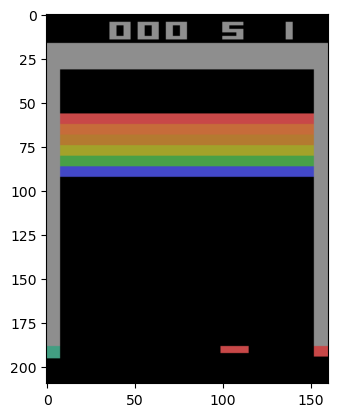

In [9]:
import gymnasium as gym
from matplotlib import pyplot as plt
import ale_py

# регистрируем среды в gym
gym.register_envs(ale_py)

# создание экземпляра среды
env = gym.make("ALE/Breakout-v5")

# обнуление среды и получение начального состояния
state, _ = env.reset()
print("Начальное состояние:")
plt.imshow(state)

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

У этой среды пространство состояний является изображением размера $210*160*3$, пиксели принимают значения от 0 до 255.

In [34]:
# создание симуляции с автоматическим рендерингом изображения
env = gym.make("ALE/Breakout-v5", render_mode = 'human')
#env = gym.make("ALE/Pong-v5", render_mode="human")
#env = gym.make("ALE/MsPacman-v5", render_mode="human")
env = gym.wrappers.RecordEpisodeStatistics(env)
state, _ = env.reset()

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
    
print("Доход:", env.return_queue)
env.close()

Доход: deque([0.0], maxlen=100)


Для сред, моделирующих игры от Atari, возникает ошибка с закрытием окна, в котором рендерится изображение. Причём вручную его можно закрыть только с ошибкой и перезапуском ядра. 

Для закрытия этого окошка без ошибки можно использовать код ниже.

In [35]:
env = gym.make("ALE/Breakout-v5", render_mode = 'human')
env.close()
env

<OrderEnforcing<PassiveEnvChecker<AtariEnv<ALE/Breakout-v5>>>>

Список всех доступных сред можно вывести командой `print(gym.envs.registry.keys())`.

In [36]:
# вывод всех доступных сред
print(gym.envs.registry.keys())

dict_keys(['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v3', 'LunarLanderContinuous-v3', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v3', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v1', 'CliffWalkingSlippery-v1', 'Taxi-v4', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Reacher-v5', 'Pusher-v2', 'Pusher-v4', 'Pusher-v5', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedPendulum-v5', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedDoublePendulum-v5', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'HalfCheetah-v5', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Hopper-v5', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Swimmer-v5', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Walker2d-v5', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', 'Humanoid-v2', 'Humanoid-v3', 

Версии используемых библиотек

In [37]:
import gymnasium
print("gymnasium version:", gymnasium.__version__)
import swig
print("swig version:", swig.__version__)
import mujoco
print("mujoco version:", mujoco.__version__)
import ale_py
print("ale_py version:", ale_py.__version__)

gymnasium version: 1.3.0
swig version: 4.4.1
mujoco version: 3.11.0
ale_py version: 0.12.0


In [2]:
import gymnasium
print("gymnasium version:", gymnasium.__version__)
import swig
print("swig version:", swig.__version__)
import mujoco
print("mujoco version:", mujoco.__version__)
import ale_py
print("ale_py version:", ale_py.__version__)

gymnasium version: 1.2.0
swig version: 4.4.1
mujoco version: 3.11.0
ale_py version: 0.12.0
